# 09 — Lane Detection with Canny + Hough Transform

**Section:** Automated Driving · **Mirrors MATLAB:** *Lane Following Control with Sensor Fusion and Lane Detection*

Classical lane detection pipeline:

1. Convert to grayscale.
2. Apply **Canny** edge detection.
3. Mask a **region-of-interest** trapezoid (road ahead).
4. Run the **probabilistic Hough transform** to extract line segments.

We synthesize a road scene so the notebook needs no external images.


In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

np.random.seed(1)

H, W = 360, 640
img = np.full((H, W, 3), (60, 60, 60), dtype=np.uint8)
# Road surface
pts_road = np.array([[100, H], [W - 100, H], [W // 2 + 70, H - 220], [W // 2 - 70, H - 220]])
cv2.fillPoly(img, [pts_road], (95, 95, 95))
# Center dashed line
for y in range(H - 200, H, 35):
    cv2.line(img, (W // 2, y), (W // 2, y + 18), (240, 220, 60), 3)
# Solid white edges
cv2.line(img, (130, H - 5), (W // 2 - 60, H - 220), (240, 240, 240), 5)
cv2.line(img, (W - 130, H - 5), (W // 2 + 60, H - 220), (240, 240, 240), 5)
img = cv2.GaussianBlur(img, (3, 3), 0)
noise = np.random.randint(-12, 12, img.shape, dtype=np.int16)
img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)


In [2]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 60, 160)

mask = np.zeros_like(edges)
roi = np.array([[(60, H), (W - 60, H), (W // 2 + 60, H - 220), (W // 2 - 60, H - 220)]])
cv2.fillPoly(mask, roi, 255)
edges_roi = cv2.bitwise_and(edges, mask)

lines = cv2.HoughLinesP(edges_roi, 1, np.pi / 180, threshold=40,
                         minLineLength=35, maxLineGap=25)

out = img.copy()
if lines is not None:
    for l in lines:
        x1, y1, x2, y2 = l[0]
        cv2.line(out, (x1, y1), (x2, y2), (0, 255, 0), 3)
print(f"Detected {0 if lines is None else len(lines)} line segments")


Detected 15 line segments


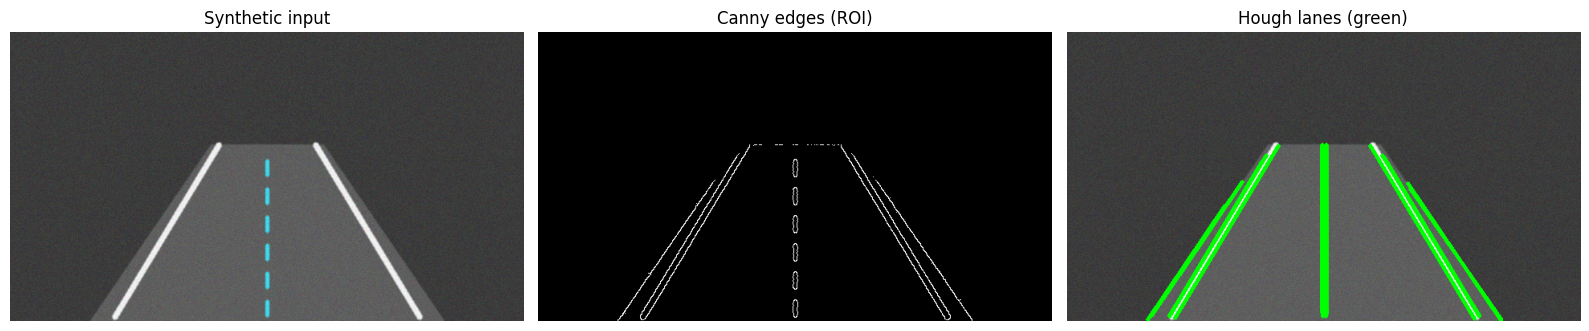

In [3]:
fig, axs = plt.subplots(1, 3, figsize=(16, 5))
axs[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axs[0].set_title('Synthetic input')
axs[1].imshow(edges_roi, cmap='gray');               axs[1].set_title('Canny edges (ROI)')
axs[2].imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB)); axs[2].set_title('Hough lanes (green)')
for ax in axs:
    ax.axis('off')
plt.tight_layout()
plt.show()
